# Federated Learning Experiments: FedAvg vs FedCC

**5 Clients | CIFAR-10**

## Tests:
| Test | Description |
|------|-------------|
| Test 1 | Normal run — all clients get IID CIFAR-10 data |
| Test 2 | Non-IID run — all clients get Non-IID CIFAR-10 data |
| Test 3 | Poisoning attack — Client 4 has Gaussian noise injected into its training images |
| Test 4 | Non-IID skew — Client 1 only gets 2 out of 10 classes |

Both **FedAvg** and **FedCC** are run on each test for comparison.

## Install Dependencies

---



In [1]:
!pip install torch torchvision numpy matplotlib scikit-learn seaborn -q

## Imports & Config

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional
from collections import OrderedDict
from functools import reduce
import os, warnings, logging

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*upfirdn2d.*")
warnings.filterwarnings("ignore", message=".*bias_act.*")

NUM_CLIENTS = 10
NUM_ROUNDS = 50
LOCAL_EPOCHS= 2
BATCH_SIZE= 256
LEARNING_RATE= 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ATTACK_CLIENT_ID   = [1, 5, 2]
GAN_WARMUP_ROUNDS = 0
BETA =0.12# gans ramp up rate
SEED=67 # six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven six seven   


n_top = 1  # CHANGE THIS to your desired n everywhere

print(f'Device: {DEVICE}')

Device: cuda


## CNN Model (CIFAR-10)

In [3]:
class CifarCNN(nn.Module):
    def __init__(self):
        super(CifarCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.conv_block(x))


def get_parameters(model):
    return [val.cpu().numpy() for val in model.state_dict().values()]


def set_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)


print('Model defined. Parameter count:',
      sum(p.numel() for p in CifarCNN().parameters()))

Model defined. Parameter count: 1107722


## Data Loading Setup

In [4]:
from collections import Counter

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

CIFAR10_TRAIN = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
CIFAR10_TEST = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

def get_all_non_iid_partitions(dataset, num_clients, alpha=0.5):
    np.random.seed(SEED)
    labels = np.array([label for _, label in dataset])
    num_classes = len(np.unique(labels))
    client_indices = [[] for _ in range(num_clients)]
    for k in range(num_classes):
        idx_k = np.where(labels == k)[0]
        np.random.shuffle(idx_k)
        proportions = np.random.dirichlet([alpha] * num_clients)
        splits = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]
        for i, chunk in enumerate(np.split(idx_k, splits)):
            client_indices[i].append(chunk)
    return [
        Subset(dataset, np.concatenate(client_indices[i]).tolist())
        for i in range(num_clients)
    ]

ALL_PARTITIONS = get_all_non_iid_partitions(CIFAR10_TRAIN, NUM_CLIENTS, alpha=0.5)

def load_client_data(client_id: int) -> Tuple[DataLoader, DataLoader]:
    train_subset = ALL_PARTITIONS[client_id]
    print(f'  [Client {client_id}]: {len(train_subset)} samples')
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(CIFAR10_TEST,  batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, test_loader

def get_top_n_classes(subset, n=1):
    labels = [subset.dataset.targets[i] for i in subset.indices]
    return [cls for cls, _ in Counter(labels).most_common(n)]

print('Data utilities ready.')
print(f'CIFAR-10 train size: {len(CIFAR10_TRAIN)} | test size: {len(CIFAR10_TEST)}')

100%|██████████| 170M/170M [01:02<00:00, 2.74MB/s]


Data utilities ready.
CIFAR-10 train size: 50000 | test size: 10000


## Pre-trained GANS Setup


In [5]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git
import pickle, requests, os,sys,contextlib
sys.path.insert(0, './stylegan2-ada-pytorch')
stylegan_path = "/kaggle/working/stylegan2-ada-pytorch"

if stylegan_path not in sys.path:
    sys.path.append(stylegan_path)


weights_url = 'https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/cifar10.pkl'
weights_path = 'cifar10.pkl'

if not os.path.exists(weights_path):
    print('Downloading StyleGAN2-ADA CIFAR-10 weights...')
    r = requests.get(weights_url, stream=True)
    with open(weights_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Done.')

with contextlib.redirect_stderr(open(os.devnull, 'w')), \
     contextlib.redirect_stdout(open(os.devnull, 'w')):
    with open(weights_path, 'rb') as f:
        data = pickle.load(f)
    stylegan_G = data['G_ema'].to(DEVICE)

print('StyleGAN2-ADA generator loaded.')
print(f'  z_dim: {stylegan_G.z_dim} | c_dim: {stylegan_G.c_dim} | img resolution: {stylegan_G.img_resolution}')



def stylegan_generate(class_idx, n_images, truncation_psi=0.7):
    with contextlib.redirect_stderr(open(os.devnull, 'w')), \
         contextlib.redirect_stdout(open(os.devnull, 'w')):
        with torch.no_grad():
            z = torch.randn(n_images, stylegan_G.z_dim).to(DEVICE)
            c = torch.zeros(n_images, stylegan_G.c_dim).to(DEVICE)
            c[:, class_idx] = 1.0
            imgs = stylegan_G(z, c, truncation_psi=truncation_psi)
            imgs = (imgs * 0.5 + 0.5).clamp(0, 1)
            imgs = (imgs - 0.5) / 0.5
    return imgs
warnings.filterwarnings("ignore", category=UserWarning, module="torch_utils")

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 7.47 MiB/s, done.
Resolving deltas: 100% (57/57), done.
Done.
StyleGAN2-ADA generator loaded.
  z_dim: 512 | c_dim: 10 | img resolution: 32


## Conditoioning on Client classes

In [6]:
topn = get_top_n_classes(ALL_PARTITIONS[ATTACK_CLIENT_ID[0]], n=n_top)
print(f'Attacker top-{n_top} classes: {[CLASSES[c] for c in topn]} {topn}')
print('StyleGAN2-ADA will generate only these classes during attack.')

Attacker top-1 classes: ['cat'] [3]
StyleGAN2-ADA will generate only these classes during attack.


## GANS Visualization

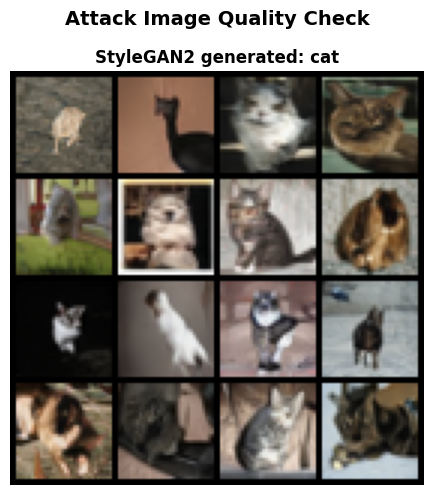

In [7]:
import torchvision.utils as vutils
fig, axes = plt.subplots(1, n_top, figsize=(6 * n_top, 5))
axes = [axes] if n_top == 1 else list(axes)

for ax, cls in zip(axes, topn):
    imgs = stylegan_generate(cls, 16, truncation_psi=0.7)
    imgs = (imgs * 0.5 + 0.5).clamp(0, 1)
    grid = vutils.make_grid(imgs, nrow=4, padding=2)
    ax.imshow(grid.permute(1, 2, 0).cpu())
    ax.set_title(f'StyleGAN2 generated: {CLASSES[cls]}', fontweight='bold')
    ax.axis('off')

plt.suptitle('Attack Image Quality Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Training and Evaluation Setup

In [8]:
def train_one_round(model, train_loader, epochs,current_round, client_id, mode='non-iid', topn_classes=None):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    is_malicious = (mode == 'attack' and client_id in ATTACK_CLIENT_ID)



    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            batch_size = images.size(0)

            if is_malicious and topn_classes is not None:
              if current_round > GAN_WARMUP_ROUNDS:
                  skew_ratio = min(0.3 + BETA  * current_round, 0.9)
                  n_skew = int(batch_size * skew_ratio)
                  n_real = batch_size - n_skew

                  idx = torch.randint(0, len(topn_classes), (1,)).item()
                  chosen_class = topn_classes[idx]

                  with torch.no_grad():
                      gan_images = stylegan_generate(chosen_class, n_skew).detach()
                  gan_labels = torch.full((n_skew,), chosen_class, dtype=torch.long, device=DEVICE)

                  images = torch.cat([images[:n_real], gan_images], dim=0)
                  labels = torch.cat([labels[:n_real], gan_labels], dim=0)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


def evaluate_model(model, test_loader):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(test_loader), correct / total

## Flower Client Class

In [9]:
class FLClient:
    """Plain federated client — no Flower dependency."""

    def __init__(self, client_id: int, mode: str = 'non-iid'):
        self.client_id   = client_id
        self.mode        = mode
        self.model       = CifarCNN()
        self.train_loader, self.test_loader = load_client_data(client_id)

        import sys
        stylegan_path = "/kaggle/working/stylegan2-ada-pytorch"
        if stylegan_path not in sys.path:
            sys.path.insert(0, stylegan_path)

        # Pre-compute top-n classes for the malicious client
        if mode == 'attack' and client_id in ATTACK_CLIENT_ID:
            self.topn_classes = get_top_n_classes(ALL_PARTITIONS[ATTACK_CLIENT_ID[0]], n=n_top)
            print(f'  [Client {client_id}] Top-{n_top} classes for GAN: '
                  f'{[CLASSES[c] for c in self.topn_classes]} {self.topn_classes}')
        else:
            self.topn_classes = None

    def get_parameters(self):
        return get_parameters(self.model)

    def fit(self, parameters, local_epochs=LOCAL_EPOCHS, current_round=0):
        set_parameters(self.model, parameters)
        train_one_round(self.model, self.train_loader,
                        local_epochs, current_round,
                        self.client_id, self.mode, self.topn_classes)
        return (get_parameters(self.model),
                len(self.train_loader.dataset),
                {'client_id': self.client_id, 'mode': self.mode})

    def evaluate(self, parameters):
        set_parameters(self.model, parameters)
        loss, accuracy = evaluate_model(self.model, self.test_loader)
        return (float(loss),
                len(self.test_loader.dataset),
                {'accuracy': float(accuracy), 'client_id': self.client_id})


print('FLClient class defined.')

FLClient class defined.


## Divergence calculation

In [10]:
# ── Client Divergence Tracking ────────────────────────────────────────────────
divergence_history = {}   # {test_name: {strategy_name: {round: {cid: {l2, cosine}}}}}

def l2_divergence(local_params, global_params):
    """L2 norm of (local − global) flattened across all weight tensors."""
    return float(np.sqrt(sum(
        np.sum((lp - gp) ** 2)
        for lp, gp in zip(local_params, global_params)
    )))

def cosine_divergence(local_params, global_params):
    """
    Cosine similarity between flattened local and global weight vectors.
    Returns similarity in [-1, 1] — closer to 1 = less diverged.
    """
    local_vec  = np.concatenate([p.ravel() for p in local_params])
    global_vec = np.concatenate([p.ravel() for p in global_params])

    dot    = np.dot(local_vec, global_vec)
    norm_l = np.linalg.norm(local_vec)
    norm_g = np.linalg.norm(global_vec)

    denom = norm_l * norm_g
    if denom < 1e-10:
        return 0.0
    return float(dot / denom)

def compute_divergence(local_params, global_params):
    local_flat  = np.concatenate([p.ravel() for p in local_params])
    global_flat = np.concatenate([p.ravel() for p in global_params])

    l2 = float(np.sqrt(np.sum((local_flat - global_flat) ** 2)))

    denom = np.linalg.norm(local_flat) * np.linalg.norm(global_flat)
    cosine = float(1.0 - np.dot(local_flat, global_flat) / denom) if denom > 1e-10 else 0.0

    return {'l2': l2, 'cosine': cosine}

# NOTE: add_divergence_tracking and add_param_snapshots are now no-ops kept for
# API compatibility. Divergence and snapshots are computed inline in run_simulation.
def add_divergence_tracking(strategy, div_log):
    strategy._div_log = div_log
    return strategy

def add_param_snapshots(strategy, snapshot_log, every_n=10):
    strategy._snapshot_log = snapshot_log
    strategy._snapshot_every_n = every_n
    return strategy

## FedAvg Setup

In [11]:
class FedAvgStrategy:
    """Modular sequential FedAvg — no Flower dependency."""

    def __init__(self, round_metrics: list):
        self.round_metrics  = round_metrics
        self._global_params = None
        # set by add_divergence_tracking / add_param_snapshots
        self._div_log         = {}
        self._snapshot_log    = {}
        self._snapshot_every_n = 10

    def aggregate_fit(self, server_round: int, results: list) -> list:
        """
        results: list of (params, num_examples, metrics)
        Returns aggregated global params (plain numpy list).
        """
        if not results:
            return self._global_params

        total_samples = sum(n for _, n, _ in results)
        aggregated = [
            sum(params[i] * n / total_samples for params, n, _ in results)
            for i in range(len(results[0][0]))
        ]
        self._global_params = aggregated
        return aggregated

    def aggregate_evaluate(self, server_round: int, results: list):
        """
        results: list of (loss, num_examples, metrics)
        """
        if not results:
            return None, {}

        total_samples = sum(n for _, n, _ in results)
        weighted_acc  = sum(m['accuracy'] * n for _, n, m in results) / total_samples
        weighted_loss = sum(loss * n for loss, n, _ in results) / total_samples

        self.round_metrics.append({
            'round': server_round,
            'accuracy': weighted_acc,
            'loss': weighted_loss
        })

        print(f'  [FedAvg] Round {server_round} — '
              f'Acc: {weighted_acc:.4f} | Loss: {weighted_loss:.4f}')

        return weighted_loss, {'accuracy': weighted_acc}


def build_fedavg_strategy(round_metrics: list) -> FedAvgStrategy:
    return FedAvgStrategy(round_metrics)


print('FedAvg strategy builder defined.')

FedAvg strategy builder defined.


## FedCC Setup

In [12]:
import math
import numpy as np
from collections import Counter, OrderedDict
from sklearn.cluster import KMeans

def _centering(K: np.ndarray) -> np.ndarray:
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H


def _rbf(X: np.ndarray, sigma=None) -> np.ndarray:
    GX = np.dot(X, X.T)
    diag_GX = np.diag(GX)
    KX = diag_GX[:, None] - GX + (diag_GX[:, None] - GX).T   # squared distances
    if sigma is None:
        nonzero = KX[KX != 0]
        mdist   = np.median(nonzero) if nonzero.size > 0 else 1.0
        sigma   = math.sqrt(mdist)
    sigma = max(sigma, 1e-10)
    KX = KX * (-0.5 / (sigma * sigma))
    return np.exp(KX)


def _kernel_HSIC(X: np.ndarray, Y: np.ndarray, sigma=None) -> float:
    return float(np.sum(_centering(_rbf(X, sigma)) * _centering(_rbf(Y, sigma))))


def _kernel_CKA(X: np.ndarray, Y: np.ndarray, sigma=None) -> float:
    hsic = _kernel_HSIC(X, Y, sigma)
    var1 = math.sqrt(_kernel_HSIC(X, X, sigma))
    var2 = math.sqrt(_kernel_HSIC(Y, Y, sigma))
    denom = var1 * var2
    if denom < 1e-10:
        return 0.0
    return float(hsic / denom)


class FedCC:
    """Modular sequential FedCC — no Flower dependency."""

    def __init__(self, round_metrics: list):
        self.round_metrics   = round_metrics
        self._global_params  = None
        # set by add_divergence_tracking / add_param_snapshots
        self._div_log         = {}
        self._snapshot_log    = {}
        self._snapshot_every_n = 10

    def aggregate_fit(self, server_round: int, results: list) -> list:
        """
        results: list of (params, num_examples, metrics)
        Returns aggregated global params (plain numpy list).
        """
        if not results:
            return self._global_params

        all_params = [params for params, _, _ in results]
        num_clients = len(all_params)

        model_ref  = CifarCNN()
        keys       = list(model_ref.state_dict().keys())

        plr_idx = len(keys) - 4

        if self._global_params is None:
            self._global_params = [
                np.mean([p[i] for p in all_params], axis=0)
                for i in range(len(all_params[0]))
            ]

        glob_plr = self._global_params[plr_idx]

        similarities = []
        for params in all_params:
            local_plr = params[plr_idx]
            val = _kernel_CKA(glob_plr, local_plr)
            similarities.append(0.0 if np.isnan(val) else val)

        similarities = np.array(similarities)
        print(f'\n  [FedCC] Round {server_round} — CKA scores per client:')
        for i, s in enumerate(similarities):
            print(f'    Client {i}: {s:.4f}')

        kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(
            similarities.reshape(-1, 1)
        )
        labels  = kmeans.labels_
        counter = Counter(labels)

        exp_sim  = np.exp(similarities)
        norm_sim = exp_sim / exp_sim.sum()   # shape: (num_clients,)

        larger_cluster        = 1 if counter[1] > counter[0] else 0
        larger_cluster_idx    = np.where(labels == larger_cluster)[0]
        smaller_cluster_idx   = np.where(labels != larger_cluster)[0]

        larger_sim         = norm_sim[larger_cluster_idx]
        larger_sim_normed  = larger_sim / larger_sim.sum()

        print(f'  [FedCC] Cluster sizes: {counter[0]} (label 0) | '
              f'{counter[1]} (label 1)  →  trusted = label {larger_cluster}')
        for i in larger_cluster_idx:
            print(f'    Client {i} | CKA={similarities[i]:.4f} | TRUSTED')
        for i in smaller_cluster_idx:
            print(f'    Client {i} | CKA={similarities[i]:.4f} | FILTERED')

        excluded_keys = set(keys[-4:])

        seg_A, seg_B, seg_C = [], [], []
        for params in all_params:
            A = np.concatenate([
                params[i].ravel()
                for i, k in enumerate(keys)
                if k not in excluded_keys
            ])
            B = np.concatenate([params[len(keys) - 4].ravel(),
                                 params[len(keys) - 3].ravel()])
            C = np.concatenate([params[len(keys) - 2].ravel(),
                                 params[len(keys) - 1].ravel()])
            seg_A.append(A)
            seg_B.append(B)
            seg_C.append(C)

        seg_A = np.stack(seg_A)
        seg_B = np.stack(seg_B)
        seg_C = np.stack(seg_C)

        agg_A = np.zeros(seg_A.shape[1])
        for idx in range(num_clients):
            agg_A += norm_sim[idx] * seg_A[idx]

        agg_B = np.zeros(seg_B.shape[1])
        for rank, client_idx in enumerate(larger_cluster_idx):
            agg_B += larger_sim_normed[rank] * seg_B[client_idx]

        agg_C = np.zeros(seg_C.shape[1])
        for idx in range(num_clients):
            agg_C += norm_sim[idx] * seg_C[idx]

        aggregated: List[np.ndarray] = []
        ptr_A, ptr_B, ptr_C = 0, 0, 0
        for i, k in enumerate(keys):
            shape = self._global_params[i].shape
            numel = int(np.prod(shape))
            if k not in excluded_keys:
                aggregated.append(agg_A[ptr_A: ptr_A + numel].reshape(shape))
                ptr_A += numel
            elif k == keys[-4] or k == keys[-3]:
                aggregated.append(agg_B[ptr_B: ptr_B + numel].reshape(shape))
                ptr_B += numel
            else:
                aggregated.append(agg_C[ptr_C: ptr_C + numel].reshape(shape))
                ptr_C += numel

        self._global_params = aggregated

        print(f'  [FedCC] Round {server_round} — '
              f'{len(larger_cluster_idx)}/{num_clients} clients trusted')

        return aggregated

    def aggregate_evaluate(self, server_round: int, results: list):
        """
        results: list of (loss, num_examples, metrics)
        """
        if not results:
            return None, {}
        total_samples = sum(n for _, n, _ in results)
        weighted_acc  = sum(m['accuracy'] * n for _, n, m in results) / total_samples
        weighted_loss = sum(loss * n for loss, n, _ in results) / total_samples
        self.round_metrics.append({
            'round': server_round,
            'accuracy': weighted_acc,
            'loss': weighted_loss
        })

        print(f'  [FedCC] Round {server_round} — Acc: {weighted_acc:.4f} | Loss: {weighted_loss:.4f}')

        return weighted_loss, {'accuracy': weighted_acc}


def build_fedcc_strategy(round_metrics: list) -> FedCC:
    return FedCC(round_metrics=round_metrics)

## Simulation Runner

In [13]:
def run_simulation(test_name: str,
                   mode: str,
                   strategy_name: str,
                   strategy) -> None:
    """
    Sequential federated learning loop — no Flower / Ray.
    Instantiates NUM_CLIENTS FLClient objects and drives rounds manually.
    """

    print(f'\n{"="*60}')
    print(f' {test_name} | Strategy: {strategy_name} | Mode: {mode}')
    print(f'{"="*60}')

    clients = [FLClient(client_id=cid, mode=mode) for cid in range(NUM_CLIENTS)]

    global_params = clients[0].get_parameters()
    strategy._global_params = [p.copy() for p in global_params]

    div_log      = getattr(strategy, '_div_log',         {})
    snapshot_log = getattr(strategy, '_snapshot_log',    {})
    every_n      = getattr(strategy, '_snapshot_every_n', 10)

    for server_round in range(1, NUM_ROUNDS + 1):

        global_snap_before = [p.copy() for p in global_params]

        fit_results = []
        for client in clients:
            params, n_samples, metrics = client.fit(
                global_params,
                local_epochs=LOCAL_EPOCHS,
                current_round=server_round
            )
            fit_results.append((params, n_samples, metrics))

        round_divs = {}
        for (local_params, _, meta) in fit_results:
            cid = meta.get('client_id', -1)
            round_divs[cid] = compute_divergence(local_params, global_snap_before)
        div_log[server_round] = round_divs

  
        global_params = strategy.aggregate_fit(server_round, fit_results)


        if server_round % every_n == 0:
            snapshot_log[server_round] = [p.copy() for p in global_params]

        
        eval_results = []
        for client in clients:
            loss, n_samples, metrics = client.evaluate(global_params)
            eval_results.append((loss, n_samples, metrics))

        strategy.aggregate_evaluate(server_round, eval_results)


print('Simulation runner defined.')

Simulation runner defined.


## Run All Tests

> **This is the main execution cell.**  
> Runs 8 simulations total: 4 tests × 2 strategies.  
> Results are stored in `all_results` for plotting.

In [14]:
all_results        = {}
divergence_history = {}
snapshots          = {}
final_params       = {}

    

TESTS = [
    ('Test 1  - Non-iid',   'non-iid'),
    ('Test 2  - Attack',   'attack'),
    


]


for test_name, mode in TESTS:
    all_results[test_name]        = {}
    divergence_history[test_name] = {}
    snapshots[test_name]          = {}
    final_params[test_name]       = {}

    for strategy_name in ['FedAvg', 'FedCC']:
        metrics      = []
        div_log      = {}
        snapshot_log = {}

        divergence_history[test_name][strategy_name] = div_log
        snapshots[test_name][strategy_name]          = snapshot_log

        if strategy_name == 'FedAvg':
            strategy = build_fedavg_strategy(metrics)
        else:
            strategy = build_fedcc_strategy(metrics)

        add_divergence_tracking(strategy, div_log)
        add_param_snapshots(strategy, snapshot_log, every_n=10)

        run_simulation(test_name, mode, strategy_name, strategy)

        all_results[test_name][strategy_name]  = metrics
        final_params[test_name][strategy_name] = strategy._global_params

print('\nAll simulations complete!')


 Test 1  - Non-iid | Strategy: FedAvg | Mode: non-iid
  [Client 0]: 7505 samples
  [Client 1]: 3766 samples
  [Client 2]: 2587 samples
  [Client 3]: 5760 samples
  [Client 4]: 5691 samples
  [Client 5]: 7494 samples
  [Client 6]: 2628 samples
  [Client 7]: 4624 samples
  [Client 8]: 5996 samples
  [Client 9]: 3949 samples
  [FedAvg] Round 1 — Acc: 0.3026 | Loss: 2.1483
  [FedAvg] Round 2 — Acc: 0.4195 | Loss: 1.6619
  [FedAvg] Round 3 — Acc: 0.4522 | Loss: 1.5136
  [FedAvg] Round 4 — Acc: 0.4873 | Loss: 1.4121
  [FedAvg] Round 5 — Acc: 0.5139 | Loss: 1.3466
  [FedAvg] Round 6 — Acc: 0.5308 | Loss: 1.2898
  [FedAvg] Round 7 — Acc: 0.5484 | Loss: 1.2403
  [FedAvg] Round 8 — Acc: 0.5692 | Loss: 1.1851
  [FedAvg] Round 9 — Acc: 0.5877 | Loss: 1.1396
  [FedAvg] Round 10 — Acc: 0.6010 | Loss: 1.1041
  [FedAvg] Round 11 — Acc: 0.6113 | Loss: 1.0749
  [FedAvg] Round 12 — Acc: 0.6285 | Loss: 1.0319
  [FedAvg] Round 13 — Acc: 0.6351 | Loss: 1.0150
  [FedAvg] Round 14 — Acc: 0.6464 | Loss: 0.985

## Results Visualization

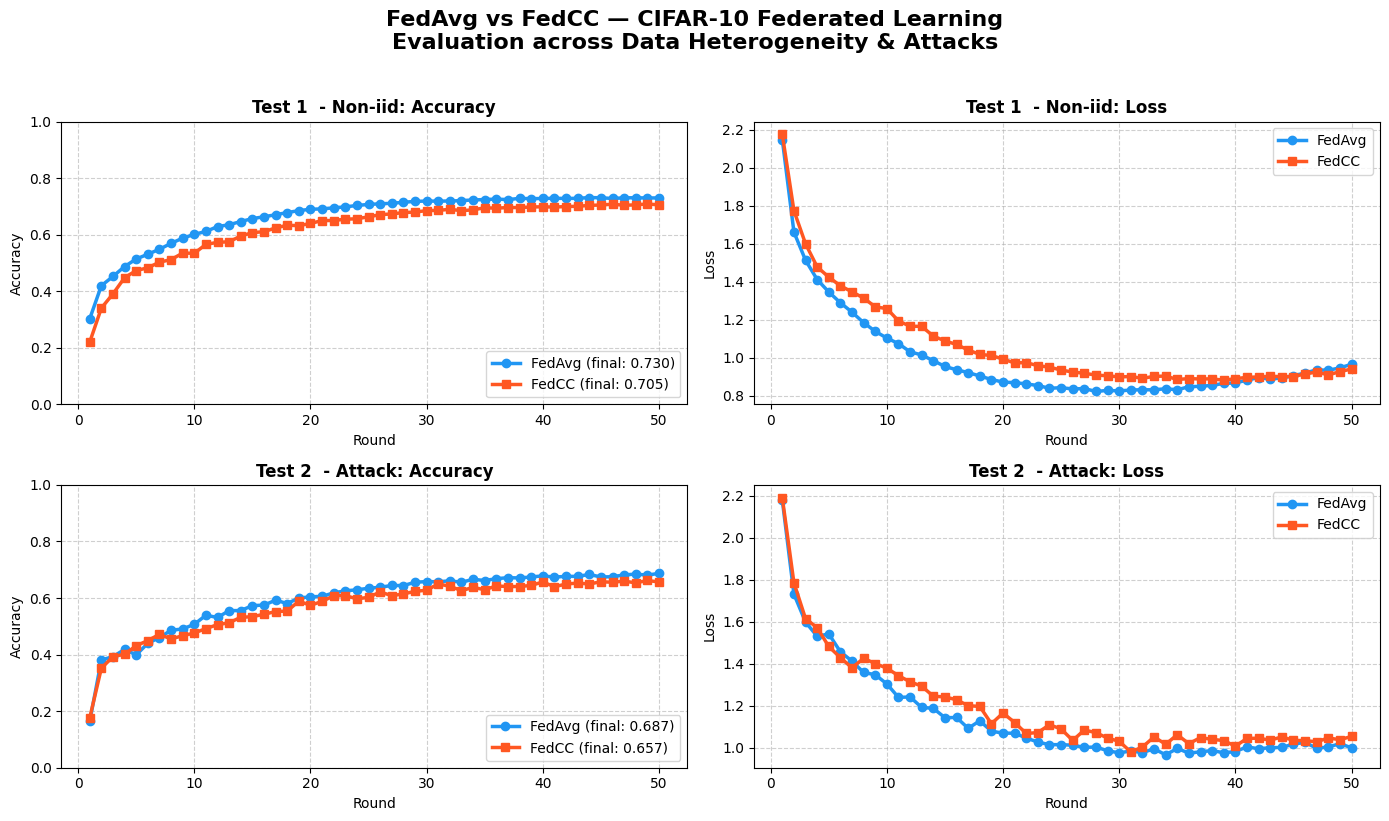

In [15]:
def plot_results(all_results: dict):
    test_names = list(all_results.keys())
    num_tests = len(test_names)

    fig, axes = plt.subplots(num_tests, 2, figsize=(14, 4 * num_tests))
    fig.suptitle('FedAvg vs FedCC — CIFAR-10 Federated Learning\nEvaluation across Data Heterogeneity & Attacks',
                 fontsize=16, fontweight='bold', y=1.02)

    colors = {'FedAvg': '#2196F3', 'FedCC': '#FF5722'}
    markers = {'FedAvg': 'o', 'FedCC': 's'}

    for row, test_name in enumerate(test_names):
        ax_acc = axes[row][0] if num_tests > 1 else axes[0]
        ax_loss = axes[row][1] if num_tests > 1 else axes[1]

        plot_data = {}

        for strategy_name, metrics in all_results[test_name].items():
            if not metrics:
                continue
            rounds = [m['round'] for m in metrics]
            accs = [m['accuracy'] for m in metrics]
            losses = [m['loss'] for m in metrics]

            plot_data[strategy_name] = (rounds, accs, losses)

            color = colors[strategy_name]
            marker = markers[strategy_name]
            final_acc = accs[-1] if accs else 0

            ax_acc.plot(rounds, accs, color=color, marker=marker,
                        label=f'{strategy_name} (final: {final_acc:.3f})',
                        linewidth=2.5, markersize=6)
            ax_loss.plot(rounds, losses, color=color, marker=marker,
                         label=strategy_name, linewidth=2.5, markersize=6)

        # Accuracy styling
        ax_acc.set_title(f'{test_name}: Accuracy', fontweight='bold', fontsize=12)
        ax_acc.set_xlabel('Round')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.set_ylim(0, 1.0)
        ax_acc.legend(loc='lower right')
        ax_acc.grid(True, linestyle='--', alpha=0.6)

        # Loss styling
        ax_loss.set_title(f'{test_name}: Loss', fontweight='bold', fontsize=12)
        ax_loss.set_xlabel('Round')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend(loc='upper right')
        ax_loss.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Call the updated function
plot_results(all_results)

## Plot Divergence

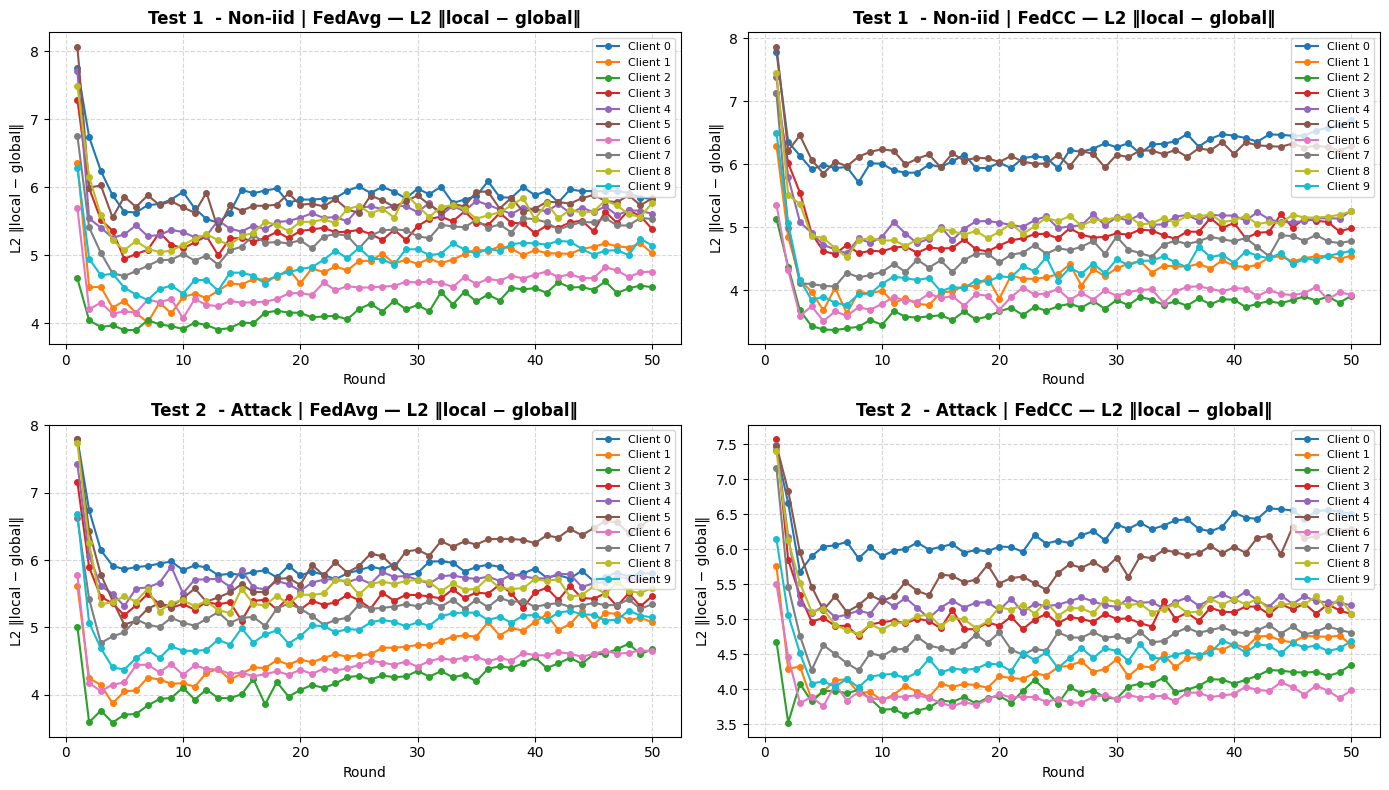

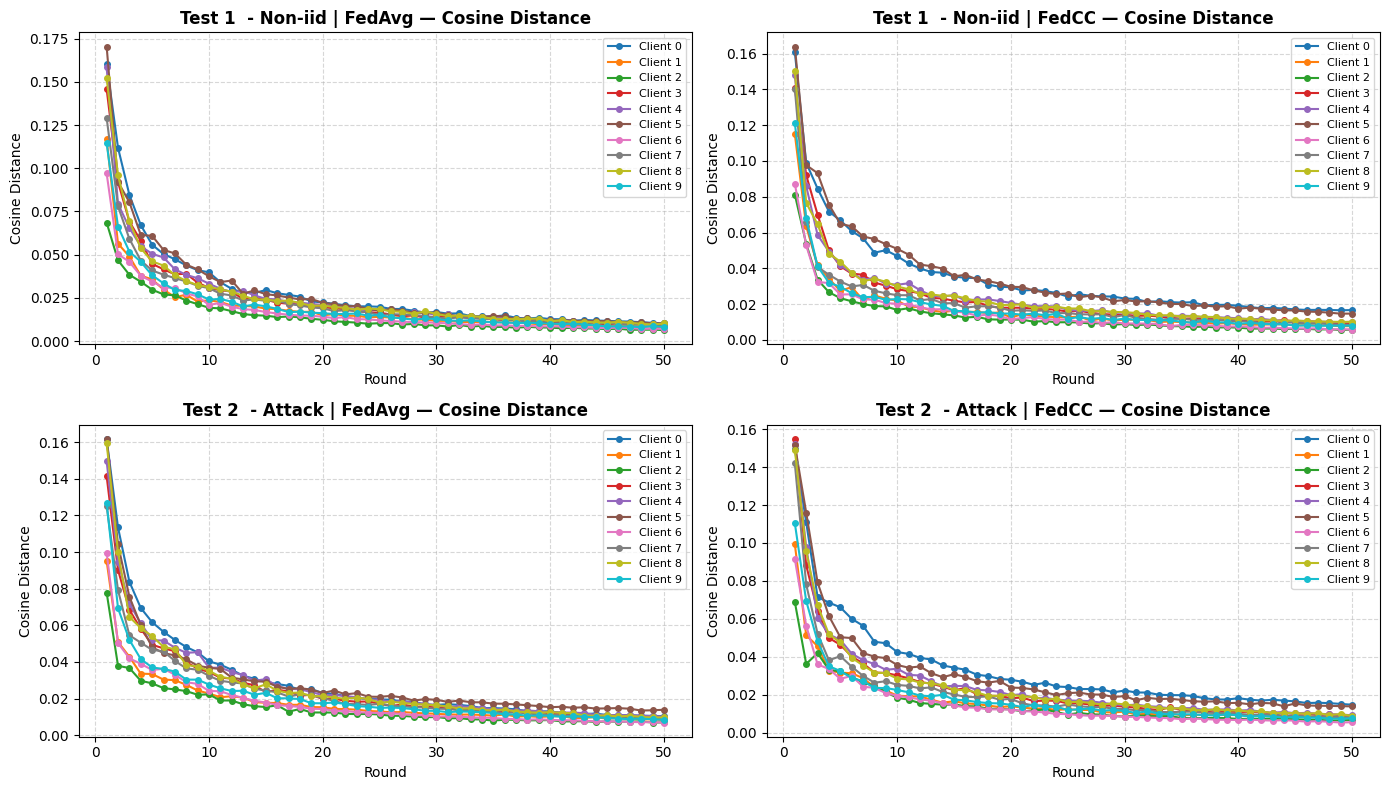

In [16]:
def plot_divergence(divergence_history, metric='l2'):
    test_names     = list(divergence_history.keys())
    strategy_names = ['FedAvg', 'FedCC']
    colors         = [f'C{i}' for i in range(NUM_CLIENTS)]

    fig, axes = plt.subplots(len(test_names), 2, figsize=(14, 4 * len(test_names)))
    if len(test_names) == 1:
        axes = [axes]

    for row, test_name in enumerate(test_names):
        for col, sname in enumerate(strategy_names):
            ax      = axes[row][col]
            div_log = divergence_history[test_name].get(sname, {})
            if not div_log:
                ax.set_visible(False)
                continue

            rounds   = sorted(div_log.keys())
            all_cids = sorted({cid for rd in div_log.values() for cid in rd})

            for cid in all_cids:
                vals = [div_log[r].get(cid, {}).get(metric, np.nan) for r in rounds]
                ax.plot(rounds, vals, marker='o', markersize=4,
                        label=f'Client {cid}', color=colors[cid])

            ylabel = {'l2': 'L2 ‖local − global‖',
                      'cosine': 'Cosine Distance'}[metric]

            ax.set_title(f'{test_name} | {sname} — {ylabel}', fontweight='bold')
            ax.set_xlabel('Round')
            ax.set_ylabel(ylabel)
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_divergence(divergence_history, metric='l2')
plot_divergence(divergence_history, metric='cosine')

## Plot Confusion Matrix

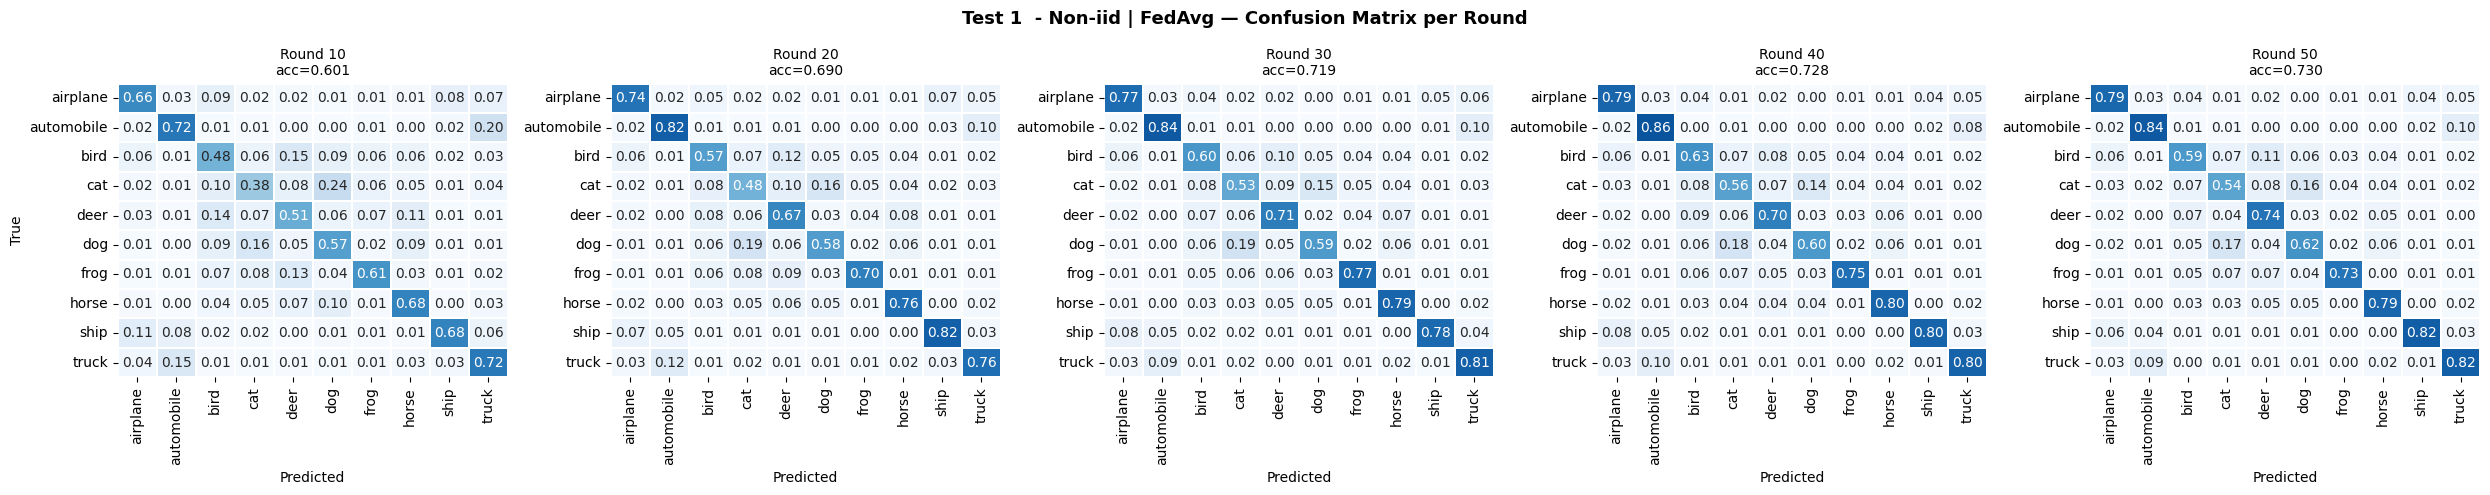

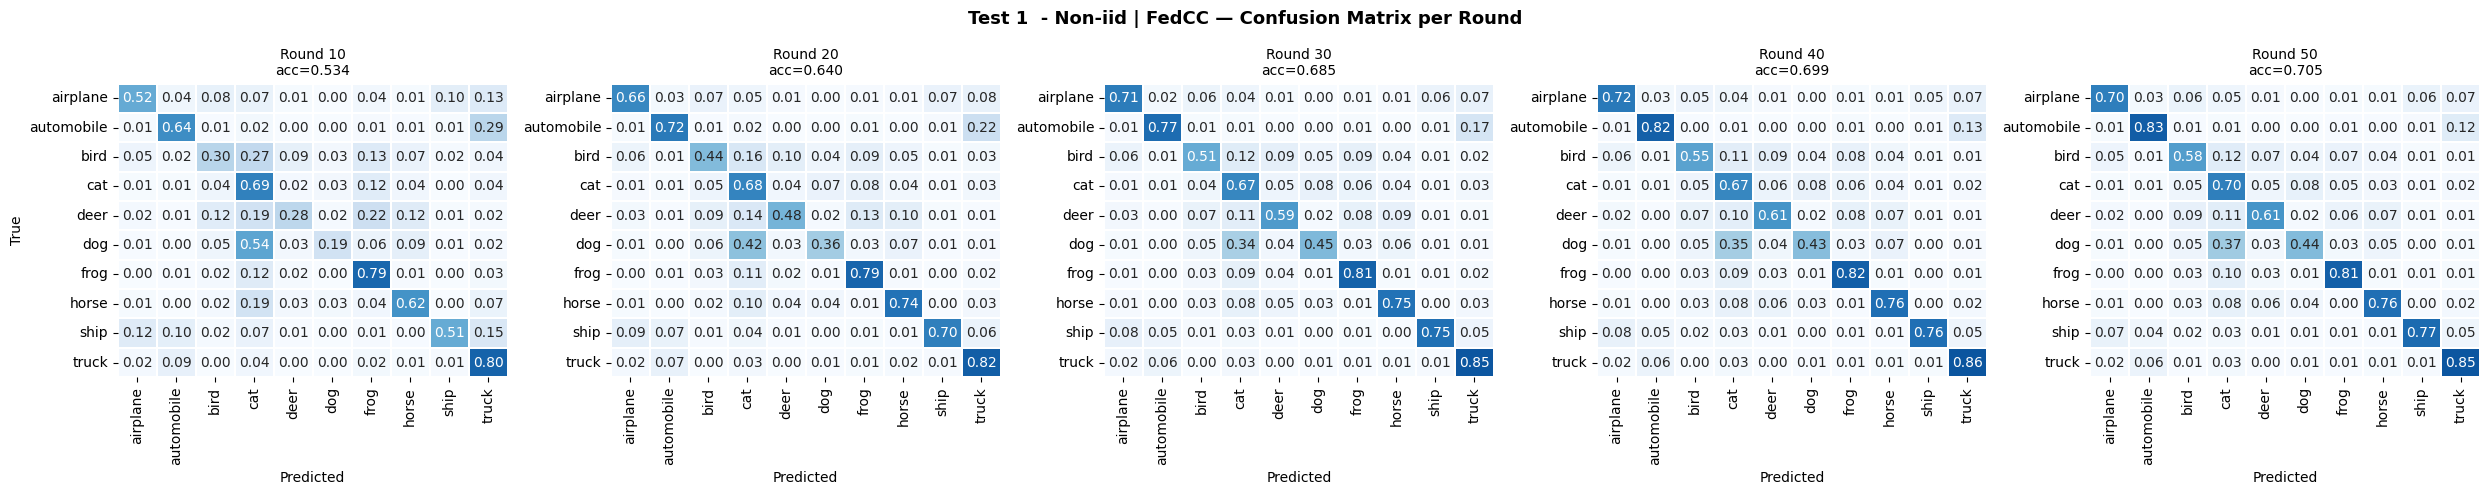

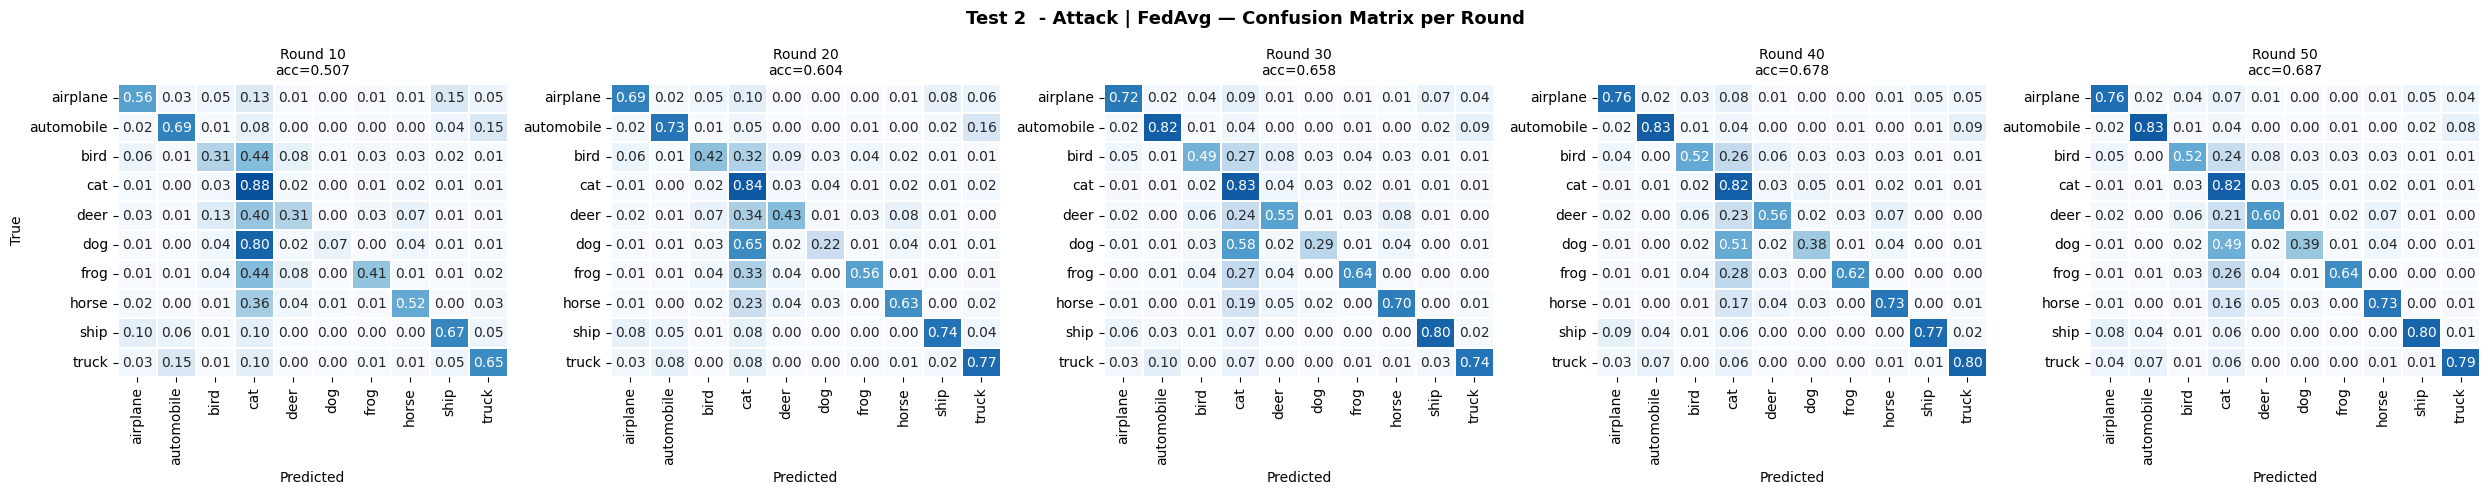

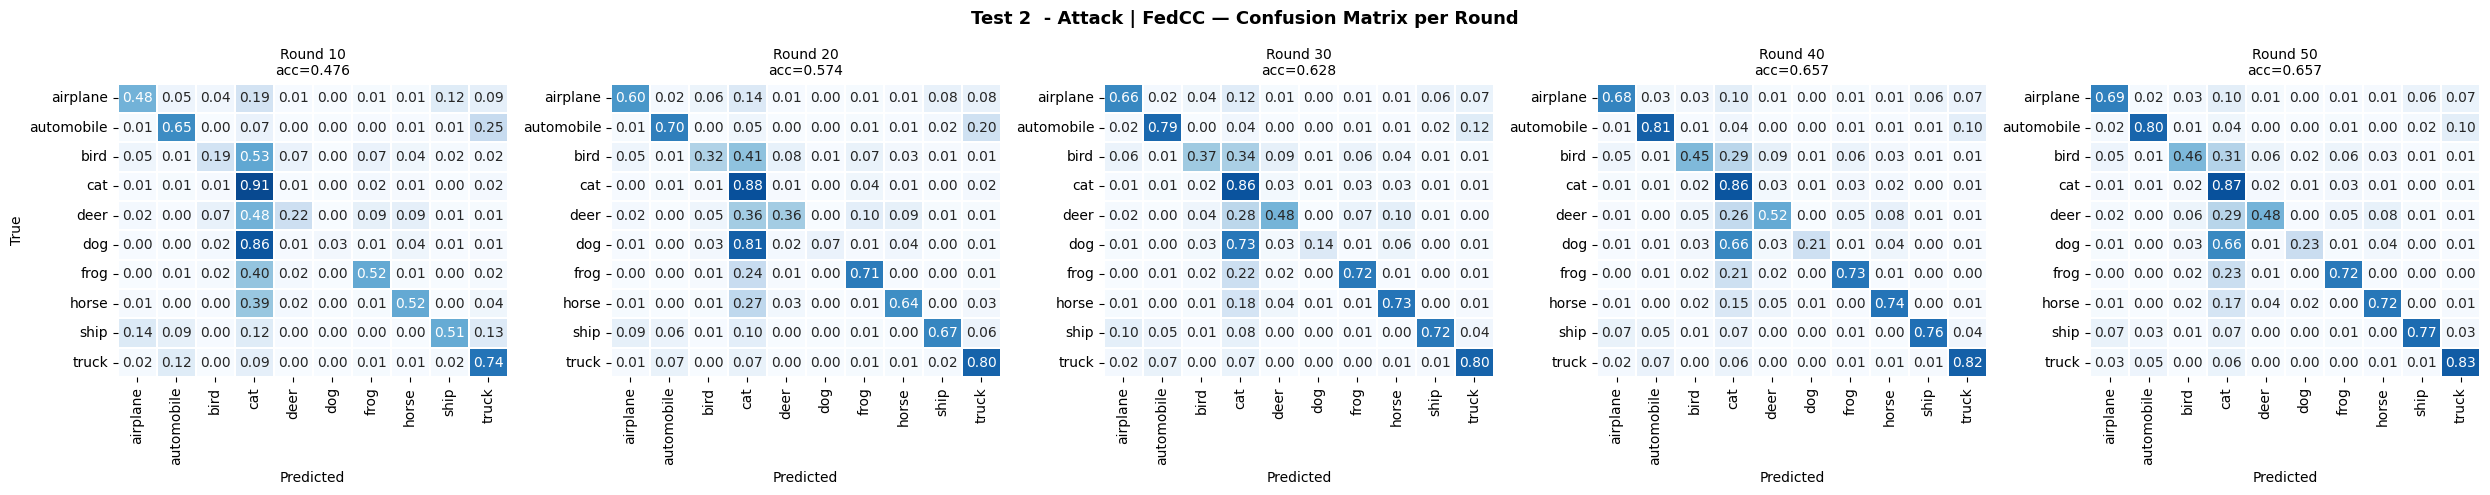

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrices_over_rounds(snapshots):
    test_loader    = DataLoader(CIFAR10_TEST, batch_size=256, shuffle=False)
    strategy_names = ['FedAvg', 'FedCC']

    for test_name in snapshots:
        for sname in strategy_names:
            snap = snapshots[test_name].get(sname, {})
            if not snap:
                continue

            rounds = sorted(snap.keys())
            n_cols = len(rounds)
            fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
            if n_cols == 1:
                axes = [axes]

            fig.suptitle(f'{test_name} | {sname} — Confusion Matrix per Round',
                         fontweight='bold', fontsize=13)

            for ax, rnd in zip(axes, rounds):
                model = CifarCNN().to(DEVICE)
                set_parameters(model, snap[rnd])
                model.eval()

                all_preds, all_labels = [], []
                with torch.no_grad():
                    for images, labels in test_loader:
                        preds = model(images.to(DEVICE)).argmax(dim=1).cpu().numpy()
                        all_preds.extend(preds)
                        all_labels.extend(labels.numpy())

                cm      = confusion_matrix(all_labels, all_preds)
                cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

                sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                            cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES,
                            linewidths=0.3, vmin=0, vmax=1, cbar=False)
                acc = np.diag(cm_norm).mean()
                ax.set_title(f'Round {rnd}\nacc={acc:.3f}', fontsize=10)
                ax.set_xlabel('Predicted')
                ax.set_ylabel('True' if rnd == rounds[0] else '')

            plt.tight_layout()
            plt.show()

plot_confusion_matrices_over_rounds(snapshots)

## Summary Table

In [18]:
print(f'\n{"="*65}')
print(f'  FINAL RESULTS SUMMARY')
print(f'{"="*65}')
print(f'{"Test":<35} {"Strategy":<10} {"Final Acc":>10} {"Final Loss":>12}')
print(f'{"-"*65}')

for test_name, strategies in all_results.items():
    for strategy_name, metrics in strategies.items():
        if metrics:
            final = metrics[-1]
            print(f'{test_name:<35} {strategy_name:<10} '
                  f'{final["accuracy"]:>10.4f} {final["loss"]:>12.4f}')
        else:
            print(f'{test_name:<35} {strategy_name:<10} {"N/A":>10} {"N/A":>12}')

print(f'{"="*65}')



  FINAL RESULTS SUMMARY
Test                                Strategy    Final Acc   Final Loss
-----------------------------------------------------------------
Test 1  - Non-iid                   FedAvg         0.7299       0.9661
Test 1  - Non-iid                   FedCC          0.7052       0.9417
Test 2  - Attack                    FedAvg         0.6873       0.9991
Test 2  - Attack                    FedCC          0.6568       1.0530
